### Machine Learning Fundamentals Day_26
***

In [1]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
insurance_data = pd.read_csv("insurance.csv")

x = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

x = pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

x['sex'] = x["sex"].map({"female":1,"male":0})
x['smoker'] = x["smoker"].map({"yes":1,"no":0})

x["age_smoker"] = x["age"] * x["smoker"]
x["bmi_smoker"] = x["bmi"] * x["smoker"]

## Train The Model
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

MSE for Alpha=0.001: 20922599.871035974
MSE for Alpha=0.1: 20921803.69843139
MSE for Alpha=1: 20914832.635089148
MSE for Alpha=2: 20908106.779954527
MSE for Alpha=5: 20890881.000633504
MSE for Alpha=10: 20872844.794796687
MSE for Alpha=20: 20877828.53237883
MSE for Alpha=40: 21046489.293890774
MSE for Alpha=50: 21196929.869608898


<Axes: >

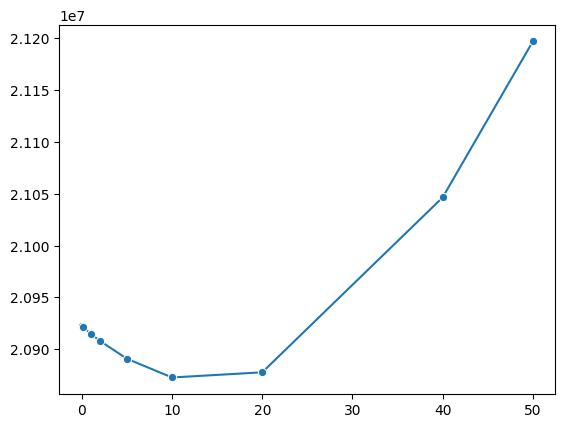

In [6]:
import seaborn as sns
alphas = [0.001,0.1,1,2,5,10,20,40,50]
mses = []

for i in alphas:
    lasso_model = Lasso(alpha=i)
    lasso_model.fit(x_train,y_train)

    y_pred = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for Alpha={i}:" ,mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")

In [7]:
## Lasso CV is the practical industry usage of lasso regression

from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(x_train,y_train)
print("Best alpha:",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("mse = ",mse)
print("s2 = ",r2)

Best alpha: 0.001
mse =  20922599.871035974
s2 =  0.8652317499151698
